In [1]:
import pandas as pd

try:
    train_df = pd.read_csv('train.csv')
    print("Train data loaded successfully. First 5 rows:")
    print(train_df.head())
except FileNotFoundError:
    print("Error: 'train.csv' not found. Please make sure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Train data loaded successfully. First 5 rows:
   id  CustomerId           Surname  CreditScore Geography  Gender   Age  \
0   0  15648047.0           Macleod        554.0    France  Female  32.0   
1   1  15664681.0         Nnachetam        710.0    France    Male  38.0   
2   2  15762605.0  Zikoranachidimma        603.0    France  Female  38.0   
3   3  15674750.0          Clements        710.0    France  Female  35.0   
4   4  15706463.0             Pinto        678.0    France    Male  34.0   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0     3.0   98649.55            1.0        0.0             1.0   
1     9.0       0.00            2.0        0.0             0.0   
2     9.0  136622.42            1.0        1.0             1.0   
3     8.0       0.00            2.0        1.0             0.0   
4     8.0       0.00            2.0        0.0             0.0   

   EstimatedSalary  Exited  
0        177099.71     0.0  
1        141872.05     0.0  
2         902

In [2]:
print("Shape of the DataFrame (rows, columns):", train_df.shape)
print("\nInformation about the DataFrame:")
train_df.info()

Shape of the DataFrame (rows, columns): (15000, 14)

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [3]:
train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15648047.0,Macleod,554.0,France,Female,32.0,3.0,98649.55,1.0,0.0,1.0,177099.71,0.0
1,1,15664681.0,Nnachetam,710.0,France,Male,38.0,9.0,0.00,2.0,0.0,0.0,141872.05,0.0
2,2,15762605.0,Zikoranachidimma,603.0,France,Female,38.0,9.0,136622.42,1.0,1.0,1.0,90212.38,0.0
3,3,15674750.0,Clements,710.0,France,Female,35.0,8.0,0.00,2.0,1.0,0.0,148811.81,0.0
4,4,15706463.0,Pinto,678.0,France,Male,34.0,8.0,0.00,2.0,0.0,0.0,148528.24,0.0


In [4]:
print("Missing values in each column:")
print(train_df.isnull().sum())

Missing values in each column:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [6]:
import pandas as pd

# Ensure train_df is defined. If the kernel was restarted or previous cells weren't run,
# this block will re-load the data to prevent NameError.
if 'train_df' not in globals():
    try:
        train_df = pd.read_csv('train.csv')
        print("Train data re-loaded as train_df was not found in the current session.")
    except FileNotFoundError:
        print("Error: 'train.csv' not found. Please make sure the file is in the correct directory.")
        # You may want to exit or raise an error here if the data is critical
        raise # Re-raise the error to stop execution if file is truly missing
    except Exception as e:
        print(f"An error occurred while re-reading the file: {e}")
        raise # Re-raise the error for other loading issues

non_numerical_cols = train_df.select_dtypes(include=['object', 'category']).columns

if not non_numerical_cols.empty:
    print("Non-numerical columns in the DataFrame:")
    for col in non_numerical_cols:
        print(f"- {col}")
else:
    print("No non-numerical columns found in the DataFrame.")

Non-numerical columns in the DataFrame:
- Surname
- Geography
- Gender


In [7]:
columns_to_drop = ['id', 'CustomerId', 'Surname']

# Drop the specified columns
# Using errors='ignore' will prevent an error if a column is not found
train_df.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')

print(f"Columns {columns_to_drop} dropped successfully.")
print("\nUpdated DataFrame head:")
print(train_df.head())
print("\nNew shape of DataFrame:", train_df.shape)

Columns ['id', 'CustomerId', 'Surname'] dropped successfully.

Updated DataFrame head:
   CreditScore Geography  Gender   Age  Tenure    Balance  NumOfProducts  \
0        554.0    France  Female  32.0     3.0   98649.55            1.0   
1        710.0    France    Male  38.0     9.0       0.00            2.0   
2        603.0    France  Female  38.0     9.0  136622.42            1.0   
3        710.0    France  Female  35.0     8.0       0.00            2.0   
4        678.0    France    Male  34.0     8.0       0.00            2.0   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0        0.0             1.0        177099.71     0.0  
1        0.0             0.0        141872.05     0.0  
2        1.0             1.0         90212.38     0.0  
3        1.0             0.0        148811.81     0.0  
4        0.0             0.0        148528.24     0.0  

New shape of DataFrame: (15000, 11)


In [8]:
import pandas as pd

# Identify non-numerical columns again, excluding the already dropped ones.
# We are left with 'Geography' and 'Gender' after dropping 'Surname'.
non_numerical_cols_for_encoding = train_df.select_dtypes(include=['object', 'category']).columns

if not non_numerical_cols_for_encoding.empty:
    print(f"Applying one-hot encoding to: {list(non_numerical_cols_for_encoding)}")
    train_df = pd.get_dummies(train_df, columns=non_numerical_cols_for_encoding, drop_first=True)
    print("One-hot encoding applied successfully.")
    print("\nUpdated DataFrame head after one-hot encoding:")
    print(train_df.head())
    print("\nNew shape of DataFrame:", train_df.shape)
else:
    print("No non-numerical columns found for one-hot encoding.")


Applying one-hot encoding to: ['Geography', 'Gender']
One-hot encoding applied successfully.

Updated DataFrame head after one-hot encoding:
   CreditScore   Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0        554.0  32.0     3.0   98649.55            1.0        0.0   
1        710.0  38.0     9.0       0.00            2.0        0.0   
2        603.0  38.0     9.0  136622.42            1.0        1.0   
3        710.0  35.0     8.0       0.00            2.0        1.0   
4        678.0  34.0     8.0       0.00            2.0        0.0   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0             1.0        177099.71     0.0              False   
1             0.0        141872.05     0.0              False   
2             1.0         90212.38     0.0              False   
3             0.0        148811.81     0.0              False   
4             0.0        148528.24     0.0              False   

   Geography_Spain  Gender_Male  
0            False 

In [9]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale. Exclude the target variable 'Exited'
# and the one-hot encoded binary columns (which are already 0/1).
# Also exclude 'HasCrCard' and 'IsActiveMember' as they are binary.

numerical_cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the identified numerical columns
train_df[numerical_cols_to_scale] = scaler.fit_transform(train_df[numerical_cols_to_scale])

print("StandardScaler applied to numerical features successfully.")
print("\nUpdated DataFrame head after scaling:")
print(train_df.head())
print("\nNew shape of DataFrame:", train_df.shape)


StandardScaler applied to numerical features successfully.

Updated DataFrame head after scaling:
   CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0    -1.415061 -0.703670 -0.743596  0.930829      -1.112662        0.0   
1     0.707510  0.032207  1.403871 -0.716825       0.773419        0.0   
2    -0.748356  0.032207  1.403871  1.565056      -1.112662        1.0   
3     0.707510 -0.335732  1.045959 -0.716825       0.773419        1.0   
4     0.272111 -0.458378  1.045959 -0.716825       0.773419        0.0   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0             1.0         1.260272     0.0              False   
1             0.0         0.512791     0.0              False   
2             1.0        -0.583353     0.0              False   
3             0.0         0.660043     0.0              False   
4             0.0         0.654026     0.0              False   

   Geography_Spain  Gender_Male  
0            False        False 

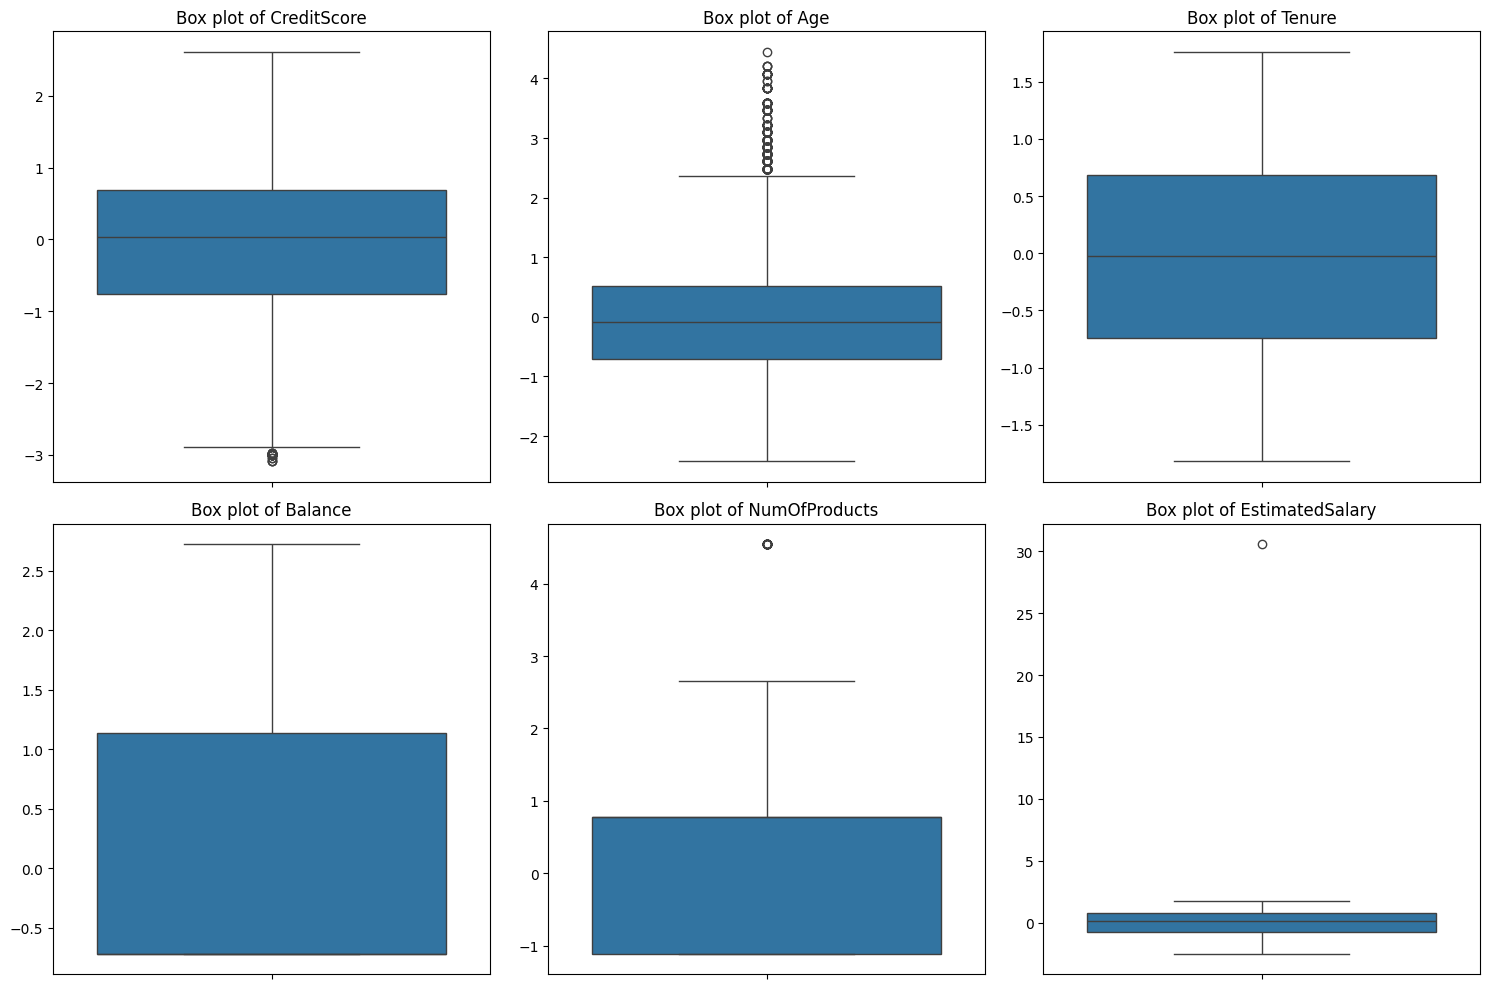

The box plots above show the distribution of the scaled numerical features. Points outside the 'whiskers' are generally considered outliers. 

You can analyze these plots to determine if there are significant outliers that need to be addressed (e.g., through capping, removal, or more advanced techniques).


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'numerical_cols_to_scale' contains the list of numerical columns that were scaled
# and are relevant for outlier detection.
numerical_cols_for_outliers = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.boxplot(y=train_df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

print("The box plots above show the distribution of the scaled numerical features. Points outside the 'whiskers' are generally considered outliers. \n\nYou can analyze these plots to determine if there are significant outliers that need to be addressed (e.g., through capping, removal, or more advanced techniques).")


In [11]:
import numpy as np

# The list of numerical columns for which we previously identified outliers
numerical_cols_for_outliers = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

print("Applying capping to outliers in the following columns:", numerical_cols_for_outliers)

for col in numerical_cols_for_outliers:
    lower_bound = train_df[col].quantile(0.01) # 1st percentile
    upper_bound = train_df[col].quantile(0.99) # 99th percentile

    # Cap the values
    train_df[col] = np.where(train_df[col] < lower_bound, lower_bound, train_df[col])
    train_df[col] = np.where(train_df[col] > upper_bound, upper_bound, train_df[col])
    print(f"  - Outliers in '{col}' capped between {lower_bound:.2f} and {upper_bound:.2f}")

print("\nOutliers capping completed successfully.")
print("\nUpdated DataFrame head after outlier capping:")
print(train_df.head())


Applying capping to outliers in the following columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
  - Outliers in 'CreditScore' capped between -2.33 and 2.61
  - Outliers in 'Age' capped between -1.81 and 2.98
  - Outliers in 'Tenure' capped between -1.82 and 1.76
  - Outliers in 'Balance' capped between -0.72 and 2.06
  - Outliers in 'NumOfProducts' capped between -1.11 and 2.66
  - Outliers in 'EstimatedSalary' capped between -2.39 and 1.49

Outliers capping completed successfully.

Updated DataFrame head after outlier capping:
   CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0    -1.415061 -0.703670 -0.743596  0.930829      -1.112662        0.0   
1     0.707510  0.032207  1.403871 -0.716825       0.773419        0.0   
2    -0.748356  0.032207  1.403871  1.565056      -1.112662        1.0   
3     0.707510 -0.335732  1.045959 -0.716825       0.773419        1.0   
4     0.272111 -0.458378  1.045959 -0.716825       0.7734

In [12]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = train_df.drop('Exited', axis=1)
y = train_df['Exited']

# Split the data into training and validation sets
# Using 80% for training and 20% for validation
# stratify=y ensures that the proportion of 'Exited' (target variable) is the same in both train and validation sets
# random_state for reproducibility
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and validation sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

print("\nDistribution of 'Exited' in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of 'Exited' in y_val:")
print(y_val.value_counts(normalize=True))

Data split into training and validation sets successfully.
X_train shape: (12000, 11)
X_val shape: (3000, 11)
y_train shape: (12000,)
y_val shape: (3000,)

Distribution of 'Exited' in y_train:
Exited
0.0    0.799833
1.0    0.200167
Name: proportion, dtype: float64

Distribution of 'Exited' in y_val:
Exited
0.0    0.8
1.0    0.2
Name: proportion, dtype: float64


/tmp/ipykernel_24997/2608612168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


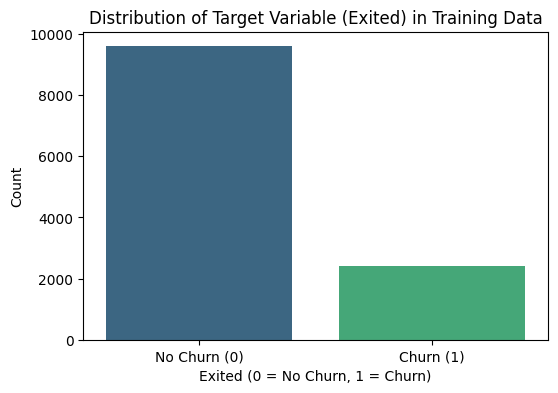

Class distribution of 'Exited' target variable:
Exited
0.0    9598
1.0    2402
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable 'Exited'
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribution of Target Variable (Exited) in Training Data')
plt.xlabel('Exited (0 = No Churn, 1 = Churn)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Churn (0)', 'Churn (1)'])
plt.show()

print("Class distribution of 'Exited' target variable:")
print(y_train.value_counts(normalize=False))

In [14]:
from sklearn.preprocessing import StandardScaler

# Identify the numerical columns that need scaling
# These are the same columns that were scaled previously
numerical_cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

print("Applying StandardScaler to numerical features in X_train and X_val...")

# Initialize a new StandardScaler
scaler_post_split = StandardScaler()

# Fit the scaler ONLY on X_train and transform X_train
X_train[numerical_cols_to_scale] = scaler_post_split.fit_transform(X_train[numerical_cols_to_scale])

# Transform X_val using the scaler fitted on X_train
X_val[numerical_cols_to_scale] = scaler_post_split.transform(X_val[numerical_cols_to_scale])

print("StandardScaler applied to training and validation sets successfully.")
print("\nUpdated X_train head after scaling:")
print(X_train.head())
print("\nUpdated X_val head after scaling:")
print(X_val.head())

Applying StandardScaler to numerical features in X_train and X_val...
StandardScaler applied to training and validation sets successfully.

Updated X_train head after scaling:
       CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
7855     -0.197196  0.777611  0.690887 -0.711508       0.785764        1.0   
2669      0.636379 -0.345622 -0.026018 -0.711508      -1.121430        0.0   
7381     -0.101540 -0.096014  0.690887 -0.711508       0.785764        0.0   
9242     -0.839459 -1.219248 -0.742923  1.667026      -1.121430        1.0   
13723    -1.126427 -1.344051  0.332435 -0.711508       0.785764        1.0   

       IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
7855              1.0         0.311351              False            False   
2669              1.0        -1.252232              False            False   
7381              0.0         1.320246              False            False   
9242              0.0         0.925827     

In [17]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Training XGBoost Classifier...")

# Initialize the XGBoost classifier
# Use 'objective="binary:logistic"' for binary classification and 'eval_metric="logloss"' for evaluation
# scale_pos_weight can be used to handle class imbalance, if necessary, by weighting the positive class.
# For now, we'll start without it to see baseline performance.
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost Classifier trained successfully.")

Training XGBoost Classifier...
XGBoost Classifier trained successfully.


In [16]:
print("Making predictions on the validation set...")

# Make predictions on the validation set
y_pred = xgb_model.predict(X_val)

# Evaluate the model
print("\n--- XGBoost Model Evaluation on Validation Set ---")
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Making predictions on the validation set...

--- XGBoost Model Evaluation on Validation Set ---
Accuracy: 0.8976666666666666

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2400
         1.0       0.79      0.66      0.72       600

    accuracy                           0.90      3000
   macro avg       0.86      0.81      0.83      3000
weighted avg       0.89      0.90      0.89      3000


Confusion Matrix:
[[2295  105]
 [ 202  398]]


In [18]:
from imblearn.over_sampling import SMOTE
import pandas as pd

print("Applying SMOTE to the training data...")

# Initialize SMOTE
# random_state for reproducibility
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("SMOTE applied successfully.")
print(f"Original training data shape: {X_train.shape, y_train.shape}")
print(f"Resampled training data shape: {X_train_resampled.shape, y_train_resampled.shape}")

print("\nClass distribution in original y_train:")
print(y_train.value_counts())

print("\nClass distribution in resampled y_train:")
print(y_train_resampled.value_counts())


Applying SMOTE to the training data...
SMOTE applied successfully.
Original training data shape: ((12000, 11), (12000,))
Resampled training data shape: ((19196, 11), (19196,))

Class distribution in original y_train:
Exited
0.0    9598
1.0    2402
Name: count, dtype: int64

Class distribution in resampled y_train:
Exited
0.0    9598
1.0    9598
Name: count, dtype: int64


In [19]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n--- Training XGBoost Classifier with SMOTE-resampled data ---")

# Initialize the XGBoost classifier (using the same parameters as before)
xgb_model_resampled = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train the model using the SMOTE-resampled training data
xgb_model_resampled.fit(X_train_resampled, y_train_resampled)

print("XGBoost Classifier trained successfully on resampled data.")

# --- Evaluate on Resampled Training Set ---
print("\n--- Evaluating on Resampled Training Set ---")
y_train_resampled_pred = xgb_model_resampled.predict(X_train_resampled)
print("Accuracy (Resampled Training):", accuracy_score(y_train_resampled, y_train_resampled_pred))
print("\nClassification Report (Resampled Training):")
print(classification_report(y_train_resampled, y_train_resampled_pred))

# --- Evaluate on Original Validation Set ---
print("\n--- Evaluating on Original Validation Set ---")
y_val_pred_resampled_model = xgb_model_resampled.predict(X_val)
print("Accuracy (Validation):", accuracy_score(y_val, y_val_pred_resampled_model))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_resampled_model))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred_resampled_model))



--- Training XGBoost Classifier with SMOTE-resampled data ---
XGBoost Classifier trained successfully on resampled data.

--- Evaluating on Resampled Training Set ---
Accuracy (Resampled Training): 0.972025421962909

Classification Report (Resampled Training):
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      9598
         1.0       0.98      0.97      0.97      9598

    accuracy                           0.97     19196
   macro avg       0.97      0.97      0.97     19196
weighted avg       0.97      0.97      0.97     19196


--- Evaluating on Original Validation Set ---
Accuracy (Validation): 0.8943333333333333

Classification Report (Validation):
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93      2400
         1.0       0.75      0.71      0.73       600

    accuracy                           0.89      3000
   macro avg       0.84      0.82      0.83      3000
weighted avg 

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Training Random Forest Classifier with SMOTE-resampled data...")

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the SMOTE-resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

print("Random Forest Classifier trained successfully.")

# --- Evaluate on Resampled Training Set ---
print("\n--- Random Forest: Evaluation on Resampled Training Set ---")
y_train_pred_rf = rf_model.predict(X_train_resampled)
print(f"Accuracy: {accuracy_score(y_train_resampled, y_train_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_train_resampled, y_train_pred_rf))

# --- Evaluate on Original Validation Set ---
print("\n--- Random Forest: Evaluation on Original Validation Set ---")
y_val_pred_rf = rf_model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

Training Random Forest Classifier with SMOTE-resampled data...
Random Forest Classifier trained successfully.

--- Random Forest: Evaluation on Resampled Training Set ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9598
         1.0       1.00      1.00      1.00      9598

    accuracy                           1.00     19196
   macro avg       1.00      1.00      1.00     19196
weighted avg       1.00      1.00      1.00     19196


--- Random Forest: Evaluation on Original Validation Set ---
Accuracy: 0.8930

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93      2400
         1.0       0.73      0.73      0.73       600

    accuracy                           0.89      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.89      0.89      0.89      3000


Confusion Matrix:
[[2241  159]

In [23]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Calculate scale_pos_weight: ratio of negative to positive classes
# sum(y == 0) / sum(y == 1)
ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"Calculated scale_pos_weight: {ratio:.2f}")

print("Searching for best hyperparameters using scale_pos_weight on original training data...")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize XGBoost with scale_pos_weight
xgb_weighted = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=ratio,
    random_state=42
)

# Initialize GridSearchCV using the original X_train (not resampled)
grid_search_weighted = GridSearchCV(estimator=xgb_weighted, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)

grid_search_weighted.fit(X_train, y_train)

# Get the best model
best_xgb_weighted = grid_search_weighted.best_estimator_
print(f"Best parameters found: {grid_search_weighted.best_params_}")

# --- Evaluate on Original Validation Set ---
print("\n--- Weighted XGBoost: Evaluation on Original Validation Set ---")
y_val_pred_weighted = best_xgb_weighted.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_weighted):.4f}")
print(classification_report(y_val, y_val_pred_weighted))

Calculated scale_pos_weight: 4.00
Searching for best hyperparameters using scale_pos_weight on original training data...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters found: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}

--- Weighted XGBoost: Evaluation on Original Validation Set ---
Accuracy: 0.8857
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93      2400
         1.0       0.70      0.76      0.73       600

    accuracy                           0.89      3000
   macro avg       0.82      0.84      0.83      3000
weighted avg       0.89      0.89      0.89      3000



In [24]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report
import numpy as np

# Initialize One-Class SVM
# 'nu' is an upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
# 'gamma' defines how far the influence of a single training example reaches.
ocsvm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')

# Train OCSVM on X_train
# Note: OCSVM is unsupervised; it typically trains on one class (the majority class) to detect anomalies.
# Here we fit it on the training features.
ocsvm.fit(X_train)

# Get predictions
# OCSVM outputs 1 for inliers and -1 for outliers.
# We need to map these to our labels (0 for No Churn, 1 for Churn) for a classification report.
# Assuming No Churn (0) is the expected 'inlier' and Churn (1) is the 'outlier'.

def map_predictions(preds):
    # Map 1 -> 0 (Inlier/No Churn) and -1 -> 1 (Outlier/Churn)
    return np.where(preds == 1, 0, 1)

train_preds_raw = ocsvm.predict(X_train)
val_preds_raw = ocsvm.predict(X_val)

y_train_ocsvm = map_predictions(train_preds_raw)
y_val_ocsvm = map_predictions(val_preds_raw)

print("--- OCSVM: Classification Report (Training Set) ---")
print(classification_report(y_train, y_train_ocsvm))

print("\n--- OCSVM: Classification Report (Validation Set) ---")
print(classification_report(y_val, y_val_ocsvm))

--- OCSVM: Classification Report (Training Set) ---
              precision    recall  f1-score   support

         0.0       0.82      0.92      0.87      9598
         1.0       0.38      0.19      0.25      2402

    accuracy                           0.78     12000
   macro avg       0.60      0.56      0.56     12000
weighted avg       0.73      0.78      0.75     12000


--- OCSVM: Classification Report (Validation Set) ---
              precision    recall  f1-score   support

         0.0       0.82      0.93      0.87      2400
         1.0       0.38      0.18      0.25       600

    accuracy                           0.78      3000
   macro avg       0.60      0.56      0.56      3000
weighted avg       0.73      0.78      0.75      3000



In [25]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

print("Training LightGBM Classifier...")

# Initialize the LightGBM classifier
# We'll use default parameters initially, similar to the baseline XGBoost approach.
lgbm_model = lgb.LGBMClassifier(random_state=42)

# Train the model
lgbm_model.fit(X_train, y_train)

print("LightGBM Classifier trained successfully.")

# --- Evaluate on Training Set ---
print("\n--- LightGBM: Classification Report (Training Set) ---")
y_train_pred_lgbm = lgbm_model.predict(X_train)
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_lgbm):.4f}")
print(classification_report(y_train, y_train_pred_lgbm))

# --- Evaluate on Validation Set ---
print("\n--- LightGBM: Classification Report (Validation Set) ---")
y_val_pred_lgbm = lgbm_model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_lgbm):.4f}")
print(classification_report(y_val, y_val_pred_lgbm))

Training LightGBM Classifier...
[LightGBM] [Info] Number of positive: 2402, number of negative: 9598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 827
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200167 -> initscore=-1.385253
[LightGBM] [Info] Start training from score -1.385253
LightGBM Classifier trained successfully.

--- LightGBM: Classification Report (Training Set) ---
Accuracy: 0.9369
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      9598
         1.0       0.89      0.78      0.83      2402

    accuracy                           0.94     12000
   macro avg       0.92      0.88      0.90     12000
weighted avg       0.94   

In [26]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

print("Starting RandomizedSearchCV for LightGBM...")

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 40, 60],
    'max_depth': [-1, 5, 10, 20],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Initialize the LightGBM classifier
lgbm_base = lgb.LGBMClassifier(random_state=42, verbose=-1)

# Initialize RandomizedSearchCV
# n_iter=20 trials to balance search quality and execution time
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit on the training data
random_search_lgbm.fit(X_train, y_train)

# Get the best estimator
best_lgbm_model = random_search_lgbm.best_estimator_
print(f"Best parameters found: {random_search_lgbm.best_params_}")

# --- Evaluate on Training Set ---
print("\n--- Optimized LightGBM: Evaluation on Training Set ---")
y_train_pred_opt = best_lgbm_model.predict(X_train)
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_opt):.4f}")
print(classification_report(y_train, y_train_pred_opt))

# --- Evaluate on Validation Set ---
print("\n--- Optimized LightGBM: Evaluation on Validation Set ---")
y_val_pred_opt = best_lgbm_model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_opt):.4f}")
print(classification_report(y_val, y_val_pred_opt))

Starting RandomizedSearchCV for LightGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found: {'subsample': 0.9, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

--- Optimized LightGBM: Evaluation on Training Set ---
Accuracy: 0.9199
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      9598
         1.0       0.85      0.72      0.78      2402

    accuracy                           0.92     12000
   macro avg       0.89      0.85      0.87     12000
weighted avg       0.92      0.92      0.92     12000


--- Optimized LightGBM: Evaluation on Validation Set ---
Accuracy: 0.9067
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2400
         1.0       0.83      0.67      0.74       600

    accuracy                           0.91      3000
   macro avg       0.87      0.

/tmp/ipykernel_24997/1642589238.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


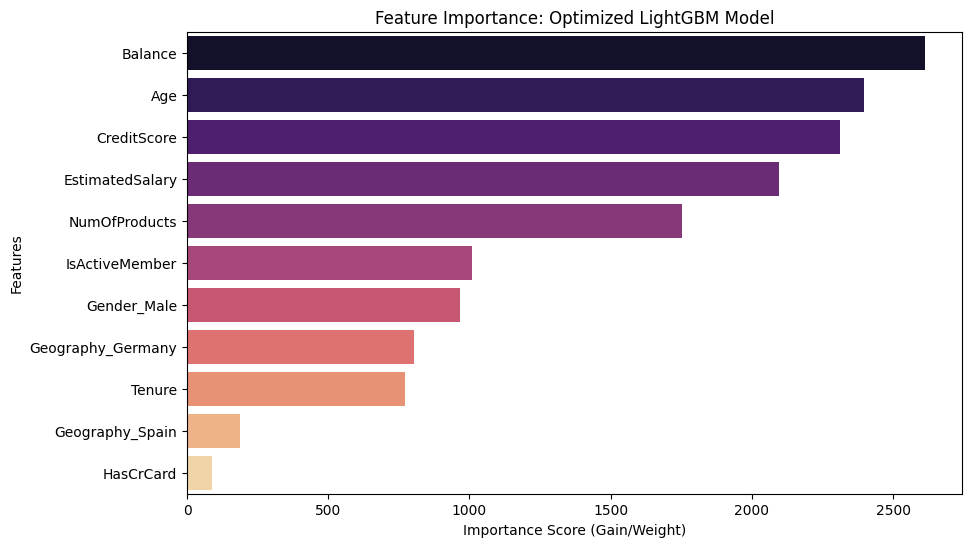

Top 5 most important features:
           Feature  Importance
3          Balance        2613
1              Age        2396
0      CreditScore        2312
7  EstimatedSalary        2096
4    NumOfProducts        1753


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importances from the best LightGBM model
feature_importances = best_lgbm_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance: Optimized LightGBM Model')
plt.xlabel('Importance Score (Gain/Weight)')
plt.ylabel('Features')
plt.show()

print("Top 5 most important features:")
print(importance_df.head(5))

In [28]:
# Load test data
test_df = pd.read_csv('test.csv')
test_ids = test_df['id']

# Preprocessing on test data
test_df.drop(columns=['id', 'CustomerId', 'Surname'], axis=1, inplace=True, errors='ignore')
test_df = pd.get_dummies(test_df, columns=['Geography', 'Gender'], drop_first=True)

# Standardize using the same scaler fitted on training data
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
test_df[numerical_cols] = scaler_post_split.transform(test_df[numerical_cols])

# Generate predictions using the optimized LightGBM model
test_predictions = best_lgbm_model.predict_proba(test_df)[:, 1]

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test_ids,
    'Exited': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Final predictions generated and saved to 'submission.csv'.")
submission.head()

Final predictions generated and saved to 'submission.csv'.


,id,Exited
0,15000,0.768983
1,15001,0.952653
2,15002,0.971218
3,15003,0.866497
4,15004,0.791220


In [30]:
import pandas as pd

# Identify boolean columns
bool_cols = train_df.select_dtypes(include=['bool']).columns

if len(bool_cols) > 0:
    print(f"Converting boolean columns to integers: {list(bool_cols)}")
    # Convert True/False to 1/0
    train_df[bool_cols] = train_df[bool_cols].astype(int)

# Final check for any remaining non-numerical columns
non_numerical_cols = train_df.select_dtypes(exclude=['number']).columns

if len(non_numerical_cols) > 0:
    print(f"\nStill found {len(non_numerical_cols)} non-numerical column(s): {list(non_numerical_cols)}")
else:
    print("\nSuccess: All columns are now numerical.")

display(train_df.head())

Converting boolean columns to integers: ['Geography_Germany', 'Geography_Spain', 'Gender_Male']

Success: All columns are now numerical.


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,-1.415061,-0.703670,-0.743596,0.930829,-1.112662,0.0,1.0,1.260272,0.0,0,0,0
1,0.707510,0.032207,1.403871,-0.716825,0.773419,0.0,0.0,0.512791,0.0,0,0,1
2,-0.748356,0.032207,1.403871,1.565056,-1.112662,1.0,1.0,-0.583353,0.0,0,0,0
3,0.707510,-0.335732,1.045959,-0.716825,0.773419,1.0,0.0,0.660043,0.0,0,0,0
4,0.272111,-0.458378,1.045959,-0.716825,0.773419,0.0,0.0,0.654026,0.0,0,0,1


In [31]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Initialize the XGBoost classifier
xgb_clf = xgb.XGBClassifier(random_state=42)

# Fit the model on the training data
xgb_clf.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_xgb = xgb_clf.predict(X_val)

# Print the classification report
print("XGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2400
         1.0       0.79      0.66      0.72       600

    accuracy                           0.90      3000
   macro avg       0.86      0.81      0.83      3000
weighted avg       0.89      0.90      0.89      3000

